In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\fraud-detection')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [14]:
fraud = pd.read_csv('data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('data/raw/IpAddress_to_Country.csv')

print(f"Fraud_Data shape: {fraud.shape}")
print(f"IP_Country shape: {ip_country.shape}")
print(f"\nFraud_Data columns: {fraud.columns.tolist()}")
print(f"\nData types:\n{fraud.dtypes}")
fraud.head()

Fraud_Data shape: (151112, 11)
IP_Country shape: (138846, 3)

Fraud_Data columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class']

Data types:
user_id             int64
signup_time        object
purchase_time      object
purchase_value      int64
device_id          object
source             object
browser            object
sex                object
age                 int64
ip_address        float64
class               int64
dtype: object


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [15]:
print("=== Summary Statistics ===")
print(fraud.describe().round(2))

print("\n=== Missing Values ===")
print(fraud.isnull().sum())

print(f"\n=== Duplicates ===")
print(f"Duplicate rows: {fraud.duplicated().sum()}")

print(f"\n=== Class Distribution ===")
print(fraud['class'].value_counts())
print(f"Fraud rate: {fraud['class'].mean()*100:.2f}%")

=== Summary Statistics ===
         user_id  purchase_value        age    ip_address      class
count  151112.00       151112.00  151112.00  1.511120e+05  151112.00
mean   200171.04           36.94      33.14  2.152145e+09       0.09
std    115369.29           18.32       8.62  1.248497e+09       0.29
min         2.00            9.00      18.00  5.209350e+04       0.00
25%    100642.50           22.00      27.00  1.085934e+09       0.00
50%    199958.00           35.00      33.00  2.154770e+09       0.00
75%    300054.00           49.00      39.00  3.243258e+09       0.00
max    400000.00          154.00      76.00  4.294850e+09       1.00

=== Missing Values ===
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

=== Duplicates ===
Duplicate rows: 0

=== Class Distribution ===
class
0    136961
1     14151

In [16]:
fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

# Time since signup (seconds)
fraud['time_since_signup'] = (
    fraud['purchase_time'] - fraud['signup_time']
).dt.total_seconds()

# Hour and day features
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek
fraud['purchase_month'] = fraud['purchase_time'].dt.month

print("Time features created!")
print(fraud[['time_since_signup','hour_of_day','day_of_week']].describe().round(2))

Time features created!
       time_since_signup  hour_of_day  day_of_week
count          151112.00    151112.00    151112.00
mean          4932029.25        11.52         3.01
std           3126263.12         6.91         2.01
min                 1.00         0.00         0.00
25%           2186753.50         6.00         1.00
50%           4926345.50        12.00         3.00
75%           7644524.50        17.00         5.00
max          10367972.00        23.00         6.00


In [17]:
# Number of transactions per user (velocity)
user_tx_count = fraud.groupby('user_id').size().reset_index(name='user_tx_count')
fraud = fraud.merge(user_tx_count, on='user_id', how='left')

# Number of transactions per device
device_tx_count = fraud.groupby('device_id').size().reset_index(name='device_tx_count')
fraud = fraud.merge(device_tx_count, on='device_id', how='left')

print("Velocity features created!")
print(f"Max transactions per user: {fraud['user_tx_count'].max()}")
print(f"Max transactions per device: {fraud['device_tx_count'].max()}")

Velocity features created!
Max transactions per user: 1
Max transactions per device: 20


In [18]:
# IPs are already stored as float integers — no conversion needed!
ip_country['lower_bound_ip_address'] = ip_country['lower_bound_ip_address'].astype(float)
ip_country['upper_bound_ip_address'] = ip_country['upper_bound_ip_address'].astype(float)

ip_country_sorted = ip_country.sort_values('lower_bound_ip_address').reset_index(drop=True)
fraud_sorted = fraud.sort_values('ip_address').reset_index(drop=True)

merged = pd.merge_asof(
    fraud_sorted,
    ip_country_sorted[['lower_bound_ip_address','upper_bound_ip_address','country']],
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

merged['country'] = merged.apply(
    lambda r: r['country']
    if pd.notna(r['upper_bound_ip_address']) and
       r['ip_address'] <= r['upper_bound_ip_address']
    else 'Unknown',
    axis=1
)
fraud = merged.copy()

print(f"Unknown countries: {(fraud['country']=='Unknown').sum()}")
print(f"\nTop 10 countries by FRAUD count:")
print(fraud[fraud['class']==1]['country'].value_counts().head(10))

Unknown countries: 21966

Top 10 countries by FRAUD count:
country
United States        5551
Unknown              1883
China                1043
Japan                 715
United Kingdom        477
Korea Republic of     380
Canada                348
France                300
Brazil                270
Germany               262
Name: count, dtype: int64


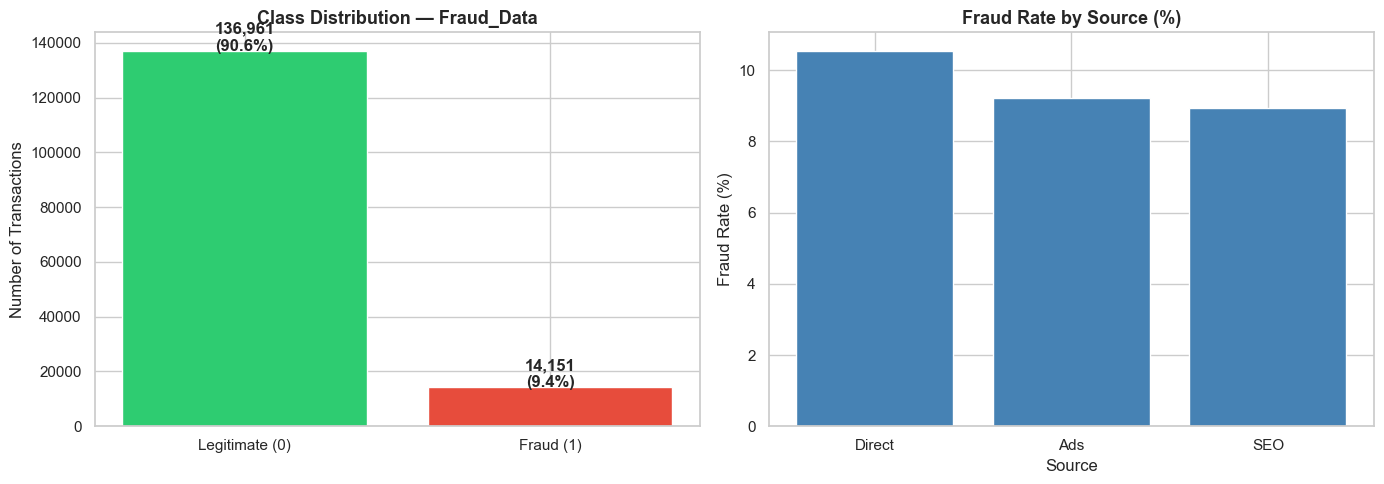

Plot 1 saved!


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = fraud['class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'],
            counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[0].set_title('Class Distribution — Fraud_Data', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+100, f'{v:,}\n({v/len(fraud)*100:.1f}%)',
                 ha='center', fontweight='bold')

fraud_by_source = fraud.groupby('source')['class'].mean().sort_values(ascending=False)
axes[1].bar(fraud_by_source.index, fraud_by_source.values*100,
            color='steelblue', edgecolor='white')
axes[1].set_title('Fraud Rate by Source (%)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('notebooks/plot1_class_imbalance.png', dpi=150)
plt.show()
print("Plot 1 saved!")

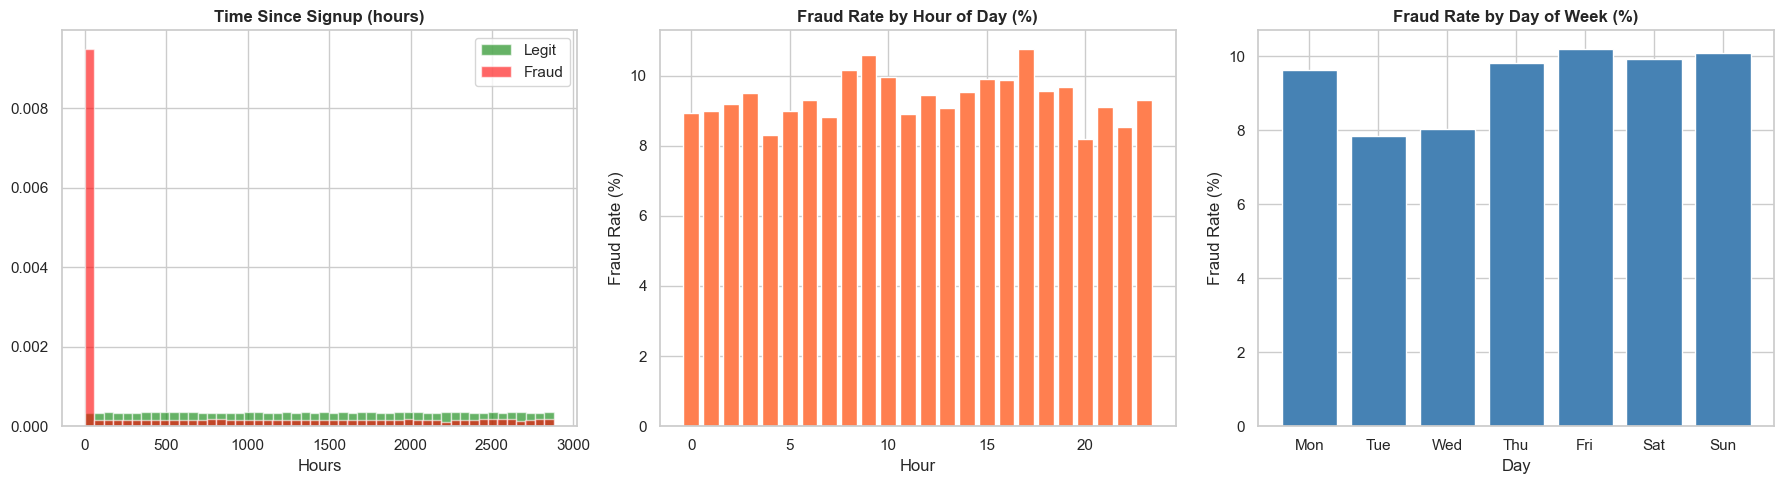

Plot 2 saved!


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fraud_pos = fraud[fraud['class']==1]['time_since_signup']/3600
fraud_neg = fraud[fraud['class']==0]['time_since_signup']/3600
axes[0].hist(fraud_neg, bins=50, alpha=0.6, color='green', label='Legit', density=True)
axes[0].hist(fraud_pos, bins=50, alpha=0.6, color='red', label='Fraud', density=True)
axes[0].set_title('Time Since Signup (hours)', fontweight='bold')
axes[0].set_xlabel('Hours')
axes[0].legend()

fraud_hour = fraud.groupby('hour_of_day')['class'].mean()*100
axes[1].bar(fraud_hour.index, fraud_hour.values, color='coral', edgecolor='white')
axes[1].set_title('Fraud Rate by Hour of Day (%)', fontweight='bold')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate (%)')

fraud_dow = fraud.groupby('day_of_week')['class'].mean()*100
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[2].bar(days, fraud_dow.values, color='steelblue', edgecolor='white')
axes[2].set_title('Fraud Rate by Day of Week (%)', fontweight='bold')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.savefig('notebooks/plot2_time_features.png', dpi=150)
plt.show()
print("Plot 2 saved!")

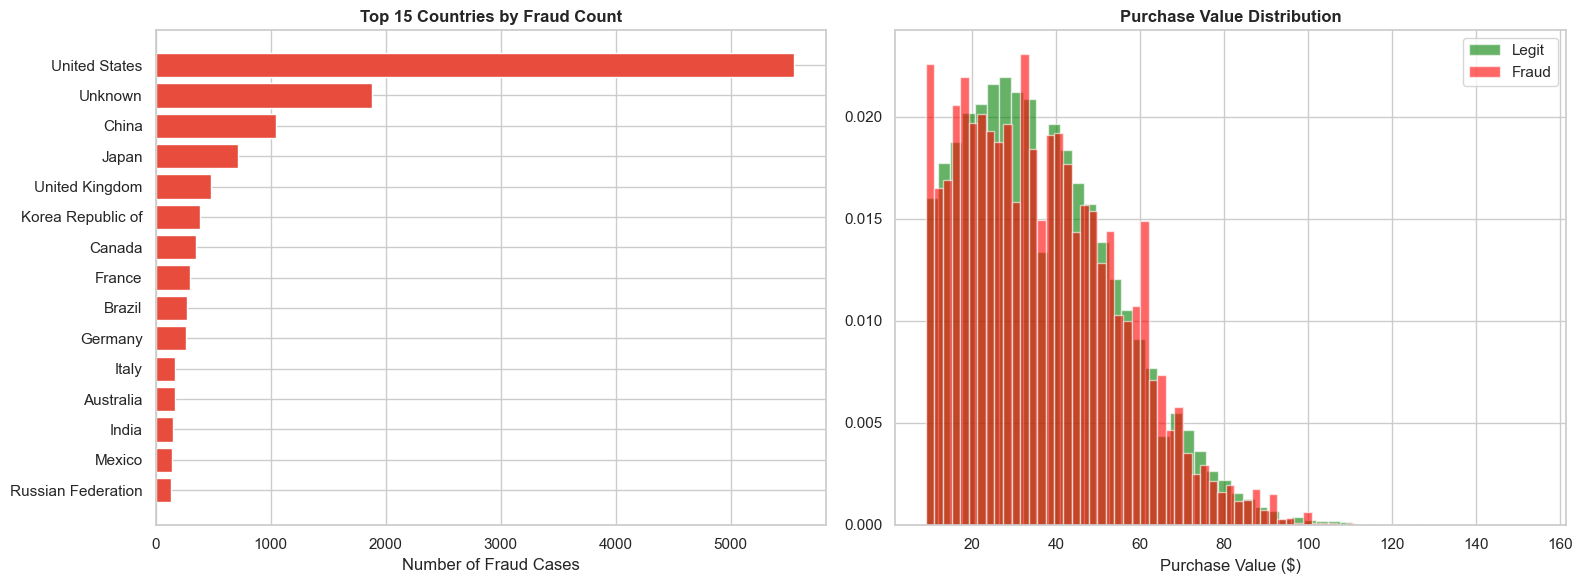

Plot 3 saved!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_countries = fraud[fraud['class']==1]['country'].value_counts().head(15)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 15 Countries by Fraud Count', fontweight='bold')
axes[0].set_xlabel('Number of Fraud Cases')

axes[1].hist(fraud[fraud['class']==0]['purchase_value'],
             bins=50, alpha=0.6, color='green', label='Legit', density=True)
axes[1].hist(fraud[fraud['class']==1]['purchase_value'],
             bins=50, alpha=0.6, color='red', label='Fraud', density=True)
axes[1].set_title('Purchase Value Distribution', fontweight='bold')
axes[1].set_xlabel('Purchase Value ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/plot3_geographic_analysis.png', dpi=150)
plt.show()
print("Plot 3 saved!")

In [22]:
# Select and save final features
feature_cols = [
    'user_id', 'purchase_value', 'source', 'browser', 'sex', 'age',
    'country', 'time_since_signup', 'hour_of_day', 'day_of_week',
    'purchase_month', 'user_tx_count', 'device_tx_count', 'class'
]
fraud_processed = fraud[feature_cols].copy()

os.makedirs('data/processed', exist_ok=True)
fraud_processed.to_csv('data/processed/fraud_features.csv', index=False)
print(f"Saved: {fraud_processed.shape}")
print(f"\nFinal fraud rate: {fraud_processed['class'].mean()*100:.2f}%")
fraud_processed.head()

Saved: (151112, 14)

Final fraud rate: 9.36%


,user_id,purchase_value,source,browser,sex,age,country,time_since_signup,hour_of_day,day_of_week,purchase_month,user_tx_count,device_tx_count,class
0,62421,46,Direct,Safari,M,36,Unknown,1763014.0,10,6,3,1,1,0
1,173212,33,Ads,IE,F,30,Unknown,1084823.0,17,4,3,1,1,0
2,242286,33,Direct,FireFox,F,32,Unknown,749320.0,8,1,5,1,1,0
3,370003,33,Ads,IE,M,40,Unknown,7434634.0,21,3,5,1,1,0
4,119824,55,Ads,Safari,M,38,Unknown,1407619.0,7,6,4,1,1,0
